# Create A COG From A GeoTIFF


In [1]:
from pathlib import Path


def find_repo_root(start: Path = Path.cwd()) -> Path:
    """Find the repository root when the kernel starts in a subfolder."""
    start = start.resolve()
    for path in (start, *start.parents):
        if (path / ".git").exists() or (path / "downloaded_data").exists():
            return path
    return start


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "downloaded_data"
DATA_DIR.mkdir(exist_ok=True)

import shutil
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import rioxarray

INPUT_FILE = DATA_DIR / "basal_melt_map_racmo_firn_air_corrected.tif"
OUTPUT_FILE = DATA_DIR / "basal_melt_map_racmo_firn_air_corrected_cog.tif"



In [2]:
def validate_cog(path: Path) -> None:
    if shutil.which("rio") is None:
        print("rio CLI is not installed; skipping rio cogeo validation.")
        return
    result = subprocess.run(
        ["rio", "cogeo", "validate", str(path)],
        text=True,
        capture_output=True,
        check=False,
    )
    print(result.stdout or result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f"COG validation failed for {path}")

## Inspect The Source Raster

We check the CRS, dimensions, block layout, and nodata value before writing the COG. The source file can still be read lazily with `rioxarray`.


In [8]:
validate_cog(INPUT_FILE)

/home/krasen/hackathon-repo/downloaded_data/basal_melt_map_racmo_firn_air_corrected.tif is NOT a valid cloud optimized GeoTIFF



In [9]:
with rasterio.open(INPUT_FILE) as src:
    print(f"CRS: {src.crs}")
    print(f"Size: {src.width} x {src.height}")
    print(f"Bounds: {src.bounds}")
    print(f"Resolution: {src.res}")
    print(f"Nodata: {src.nodata}")
    print(f"Tiled: {src.is_tiled}")
    print(f"Block shapes: {src.block_shapes}")

da = rioxarray.open_rasterio(INPUT_FILE, masked=True, chunks={"x": 2048, "y": 2048})
da


CRS: EPSG:3031
Size: 6120 x 6435
Bounds: BoundingBox(left=-3060277.25, bottom=-3217740.25, right=3059722.75, top=3217259.75)
Resolution: (1000.0, 1000.0)
Nodata: -3.4028234663852886e+38
Tiled: False
Block shapes: [(1, 6120)]


<xarray.DataArray (band: 1, y: 6435, x: 6120)> Size: 158MB
dask.array<open_rasterio-a44ab1e321915d4205e23ad9fd51ef13<this-array>, shape=(1, 6435, 6120), dtype=float32, chunksize=(1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 49kB -3.06e+06 -3.059e+06 ... 3.058e+06 3.059e+06
  * y            (y) float64 51kB 3.217e+06 3.216e+06 ... -3.216e+06 -3.217e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

## Write The COG

`driver="COG"` asks GDAL/rasterio to create a cloud-optimized layout. Compression reduces object-store transfer size; 512-pixel blocks are a common starting point for analytical rasters.


In [10]:
COG_OPTIONS = {
    "driver": "COG",
    "compress": "DEFLATE",
    "blocksize": 512,
    "overview_resampling": "nearest",
    "BIGTIFF": "IF_SAFER",
}

da.rio.to_raster(OUTPUT_FILE, **COG_OPTIONS)
print(f"Wrote {OUTPUT_FILE}")
print(f"Source size: {INPUT_FILE.stat().st_size / 1024**2:.1f} MiB")
print(f"COG size:    {OUTPUT_FILE.stat().st_size / 1024**2:.1f} MiB")


Wrote /home/krasen/hackathon-repo/downloaded_data/basal_melt_map_racmo_firn_air_corrected_cog.tif
Source size: 150.3 MiB
COG size:    7.4 MiB


In [11]:
validate_cog(OUTPUT_FILE)


/home/krasen/hackathon-repo/downloaded_data/basal_melt_map_racmo_firn_air_corrected_cog.tif is a valid cloud optimized GeoTIFF



Total overview levels found: 4


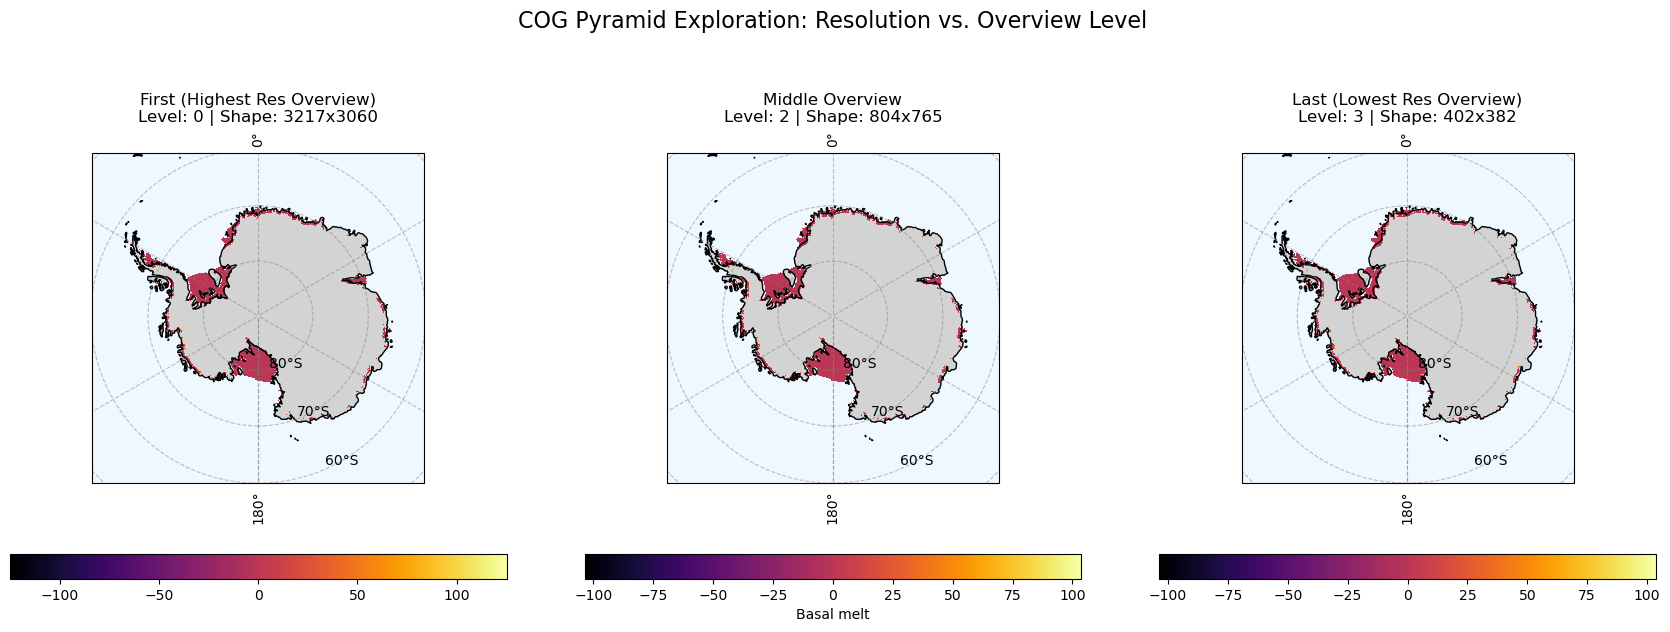

In [13]:
import rioxarray
import rasterio
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Define the path to your saved COG
cog_path = OUTPUT_FILE

with rasterio.open(cog_path) as src:
    overviews = src.overviews(1)
    num_overviews = len(overviews)

print(f"Total overview levels found: {num_overviews}")

# 3. Calculate First, Middle, and Last indices
# rioxarray uses 0-based indexing for overviews
first_level = 0
middle_level = num_overviews // 2
last_level = num_overviews - 1

levels_to_plot = [
    ("First (Highest Res Overview)", first_level),
    ("Middle Overview", middle_level),
    ("Last (Lowest Res Overview)", last_level)
]

# 4. Set up a 1x3 matplotlib figure with Cartopy projections
proj = ccrs.SouthPolarStereo()
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': proj})

# 5. Loop through our chosen levels and axes
for ax, (title_label, level_idx) in zip(axes, levels_to_plot):
    
    # Load just this specific overview level into memory
    da_overview = rioxarray.open_rasterio(
        cog_path, 
        overview_level=level_idx, 
        masked=True
    ).sel(band=1)
    
    # Set up map extent and basemap features
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='aliceblue', zorder=0)
    ax.coastlines(resolution='50m', color='black', linewidth=1, zorder=2)
    ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    
    # Plot the data onto the current axis
    da_overview.plot.pcolormesh(
        ax=ax,
        x='x',
        y='y',
        transform=proj,
        cmap='inferno',
        zorder=1, 
        cbar_kwargs={
            'orientation': 'horizontal',
            'shrink': 0.8,
            'label': 'Basal melt' if ax == axes[1] else '' # Only label middle colorbar to save space
        }
    )
    
    # Update the title with dynamic shape information
    shape_str = f"{da_overview.shape[0]}x{da_overview.shape[1]}"
    ax.set_title(f"{title_label}\nLevel: {level_idx} | Shape: {shape_str}", fontsize=12)

plt.suptitle("COG Pyramid Exploration: Resolution vs. Overview Level", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()
